In [27]:
# -*- coding: utf-8 -*-
"""
Created on Mon Sep 23 19:02:05 2024

@author: Ben
"""
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import fft
from sklearn.decomposition import PCA ## need this for principle component analysis below
from matplotlib.mlab import psd
from scipy.optimize import minimize, curve_fit
from scipy.stats import chi2
import os
from scipy.signal import welch
from scipy.signal.windows import blackman
from scipy.signal import find_peaks
from matplotlib.pyplot import gca
import h5py
#from mpl_toolkits.axes_grid1.inset_locator import (inset_axes, InsetPosition,mark_inset)
import pyfonts

#Set global plotting parameters
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['figure.dpi'] = 600

font = pyfonts.load_google_font("Average Sans")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ['Verdana']#, "DejaVu Sans", "Liberation Sans", "Verdana", "Arial", "Helvetica", "sans-serif"]
SIZE_DEFAULT = 8
plt.rcParams["font.size"] = SIZE_DEFAULT
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = SIZE_DEFAULT
plt.rcParams["ytick.labelsize"] = SIZE_DEFAULT
fig_width = 6 # inches
fig_height = 6  # inches
plt.rcParams["figure.figsize"] = (fig_width, fig_height)

wong_colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7', '#F0E442', '#0072B2', '#D55E00', '#000000']





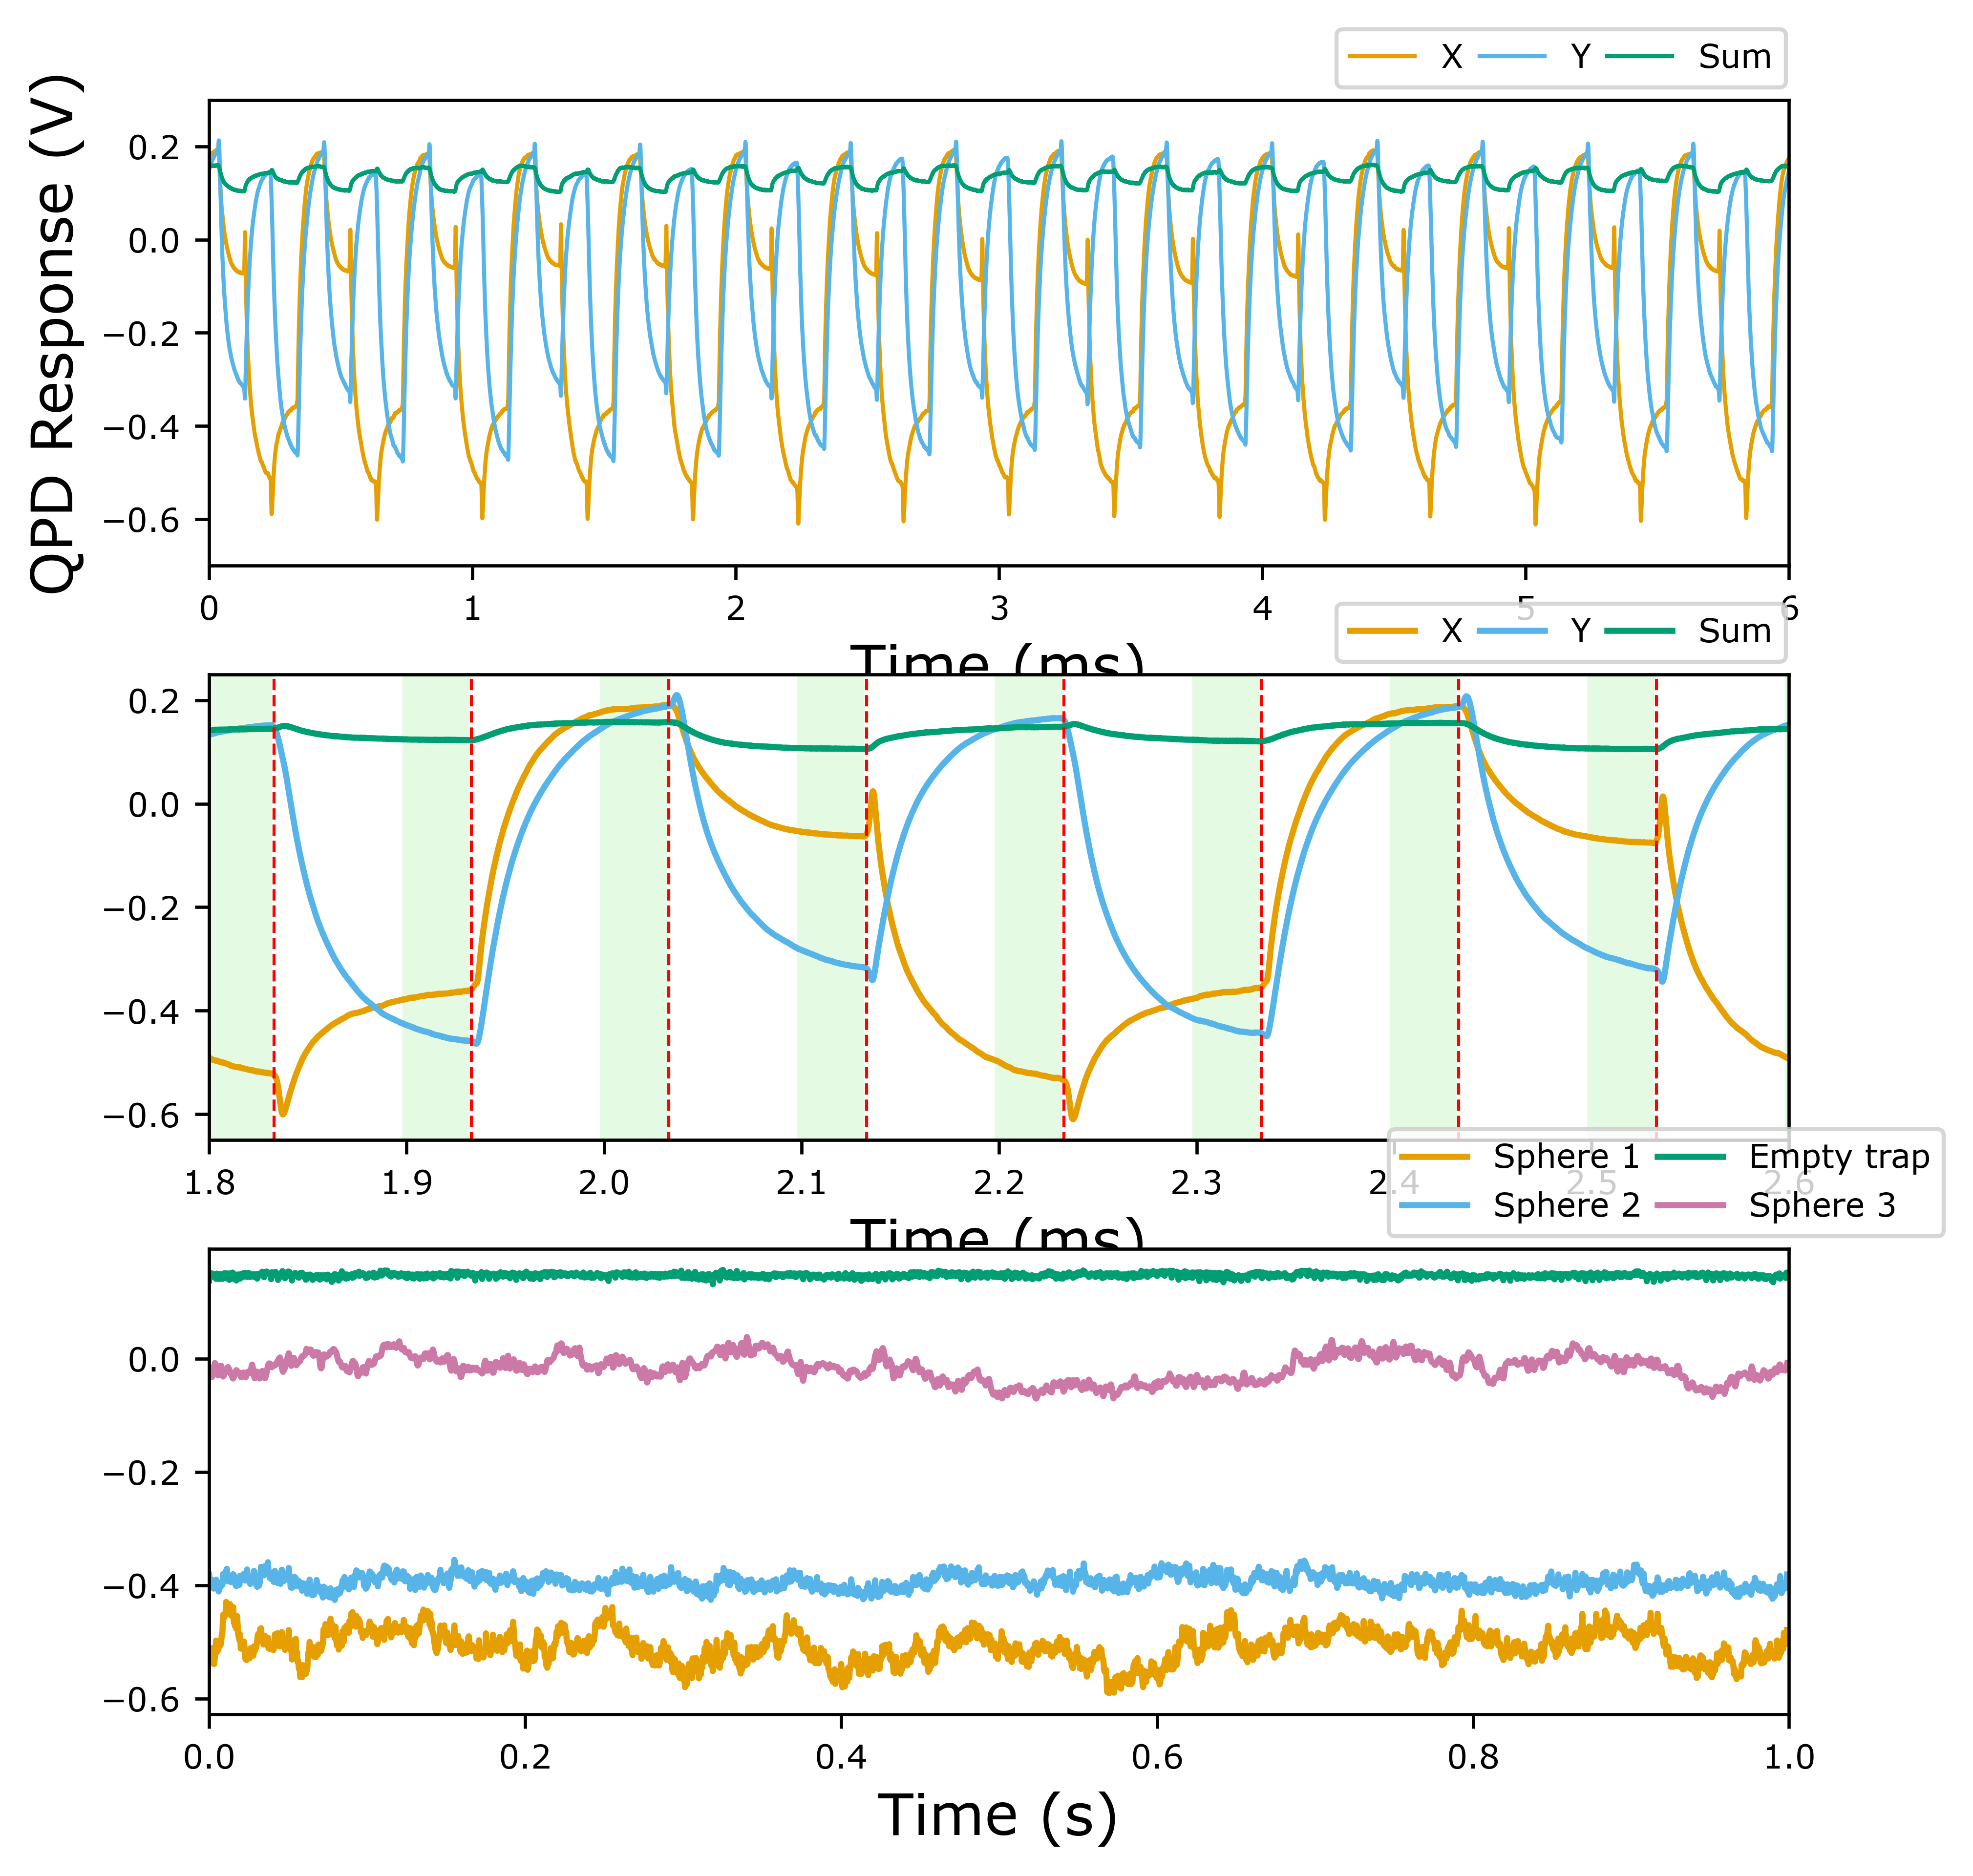

In [28]:
filenamelist = [r"F:\Lab data\20240919\QPD\4beams3trapped_AIstream_0.h5", r"F:\Lab data\20240919\QPD\4beams3trapped_AIstream_1.h5", r"F:\Lab data\20240919\QPD\4beams3trapped_AIstream_2.h5", r"F:\Lab data\20240919\QPD\4beams3trapped_AIstream_3.h5", r"F:\Lab data\20240919\QPD\4beams3trapped_AIstream_4.h5"]
counter=0
lastindex = 0
locoffset = 0
for filename in filenamelist:
    hf = h5py.File(filename, 'r')
    position_data= hf.get('unsorted_pos_data')

    sampleT = hf.attrs['Fsamp']
    CH0 = np.array(position_data[0,:])
    CH1 = np.array(position_data[1,:])
    CH2 = np.array(position_data[2,:])
    trig = np.array(position_data[3,:])
    time = (np.arange(len(CH0))+counter*len(CH0)) * sampleT *1e6 #converted to us
    hf.close()


    changelocs = []
    for i in range(len(trig)):
        if trig[i] != trig[i-1]:
            changelocs.append(i)    

    if counter != 0:
        startloc = 0
        for i in range(1,len(trig)):
            if trig[i] == lastindex and trig[i] != trig[i-1]:
                startloc = i + locoffset
                break

    if counter ==0:
        df = pd.DataFrame({'Time': time, 'CH0': CH0, 'CH1': CH1, 'CH2': CH2, 'trig':trig})
        triglocs = []
        for i in range(len(trig)):
            if trig[i] != trig[i-1]:
                triglocs.append(i+38)
    else:
        
        newdf = pd.DataFrame({'Time': time[startloc:], 'CH0': CH0[startloc:], 'CH1': CH1[startloc:], 'CH2': CH2[startloc:], 'trig':trig[startloc:]})
        df = pd.concat([df,newdf],ignore_index=True)
    
    lastindex = trig[-1]
    locoffset = len(trig) - changelocs[-1]
    counter +=1


Time = (np.arange(len(df.Time))) * sampleT *1e3 #converted to ms)
fig1, ax = plt.subplots(3,1)
fig1.tight_layout()
ax[0].tick_params(axis='both', which='major')
ax[2].tick_params(axis='both', which='major')
ax[0].plot(Time,df.CH0, color=wong_colors[0],linewidth=1)
ax[0].plot(Time,df.CH1, color=wong_colors[1],linewidth=1)
ax[0].plot(Time,df.CH2, color=wong_colors[2],linewidth=1)

# ax2 = inset_axes(ax[0], width='40%', height='65%')
# ip = InsetPosition(ax[0], [0.15,0.1,0.4,0.65])
# ax2.set_axes_locator(ip)
# mark_inset(ax[0], ax2, loc1=1, loc2=3, fc="none", ec='0.5')

ax[1].set_ylim(-0.65,0.25)
ax[1].tick_params(axis='both', which='major')
ax[1].set_xlim(Time[9000],Time[13000])
ax[1].plot(Time[9000:13000],df.CH0[9000:13000], color=wong_colors[0])
ax[1].plot(Time[9000:13000],df.CH1[9000:13000], color=wong_colors[1])
ax[1].plot(Time[9000:13000],df.CH2[9000:13000], color=wong_colors[2])
#ax2.plot(df.Time*1E6,df.trig)
y = np.arange(-1,1,0.001)
for i in range(len(triglocs)-1):
    
    if 8000<triglocs[i]<13500:
        ax[1].vlines(Time[triglocs[i]],-1, 1, colors = 'r', linestyles = 'dashed', linewidths = 0.75)
        ax[1].fill_betweenx(y, Time[triglocs[i]] + 0.065, Time[triglocs[i+1]] - 0.001, facecolor='#aaf0a1',alpha=0.3)
ax[0].legend(['X','Y', 'Sum'],loc = 'lower right', ncols=3, fontsize=8,  bbox_to_anchor=(1, 1.02), borderaxespad=0.1, columnspacing=0.5, markerscale=0.5)
ax[0].set_xlabel(r'Time (ms)')
ax[0].set_ylabel('QPD Response (V)')
ax[0].set_xlim(Time[0],Time[len(CH0)])
ax[0].set_ylim(-0.7,0.3)
#ax[0,0].set_title('Signal from Quadrant Photodiode',fontsize=22)

ax[1].legend(['X','Y', 'Sum'],loc = 'lower right', ncols=3, fontsize=8,  bbox_to_anchor=(1, 1.02), borderaxespad=0.1, columnspacing=0.5, markerscale=0.5)
ax[1].set_xlabel(r'Time (ms)')
#ax[1].set_ylabel('QPD Response (V)',fontsize=16)
#ax2.set_title('Timestream of Quadrant Photodiode for 4 Spheres',fontsize=28,pad=15)


beamsorted_file = r'F:\Lab data\20240919\QPD\4beams3trapped_beamsorted_0.h5'

hf = h5py.File(beamsorted_file, 'r')
sum_data= hf.get('SUM')
x_data= hf.get('X')
y_data= hf.get('Y')
sampleT = hf.attrs['Fsamp']
framerate = 1/sampleT
sphere0 = np.array(x_data[0,:])
sphere1 = np.array(x_data[1,:])
sphere2 = np.array(x_data[2,:])
sphere3 = np.array(x_data[3,:])
x = np.array(x_data[:,:])
time = (np.arange(len(sphere0))) * sampleT
hf.close()

ax[2].plot(time,sphere0, label = 'Sphere 1', color=wong_colors[0])
ax[2].plot(time,sphere1, label = 'Sphere 2', color=wong_colors[1])
ax[2].plot(time,sphere2, label = 'Empty trap', color=wong_colors[2])
ax[2].plot(time,sphere3, color=wong_colors[3] ,label = 'Sphere 3')

handles, labels = ax[2].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[2].legend(by_label.values(), by_label.keys(), loc = 'lower right', ncols=len(labels)/2, fontsize=8,  bbox_to_anchor=(1.1, 1.02), borderaxespad=0.1, columnspacing=0.5, markerscale=0.5)
ax[2].set_xlabel(r'Time (s)')
#ax[2].set_ylabel('QPD Response (V)',fontsize=16)
ax[2].set_xlim(time[0],1)
#ax[2].set_title('X Signal Sorted by Sphere',fontsize=22)


# segmentsize = round(framerate/5)
# for i in range(x.shape[0]):
#     xcentered = x[i,:] - np.mean(x[i,:])
#     xfreq, xPSD = welch(xcentered, framerate, 'hann', segmentsize)
#     xASD = np.sqrt(xPSD)
#     ax[1,1].semilogy(xfreq,xASD)

# ax[1,1].legend(['Sphere 1','Sphere 2','Empty trap','Sphere 3'],loc = 'upper right',fontsize=12)
# ax[1,1].set_ylabel(r'ASD ($m/ \sqrt{Hz}$)',fontsize=20)
# ax[1,1].set_xlabel('Frequency (Hz)',fontsize=20)

#ax[1,1].set_title('Signal from Quadrant Photodiode',fontsize=22)

plt.show()